<a href="https://colab.research.google.com/github/prabishkhadka/7316/blob/main/HighBoostFilter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# High-Boost Filtering (Sharpening)

**Goal:** Enhance edges/details while keeping the original image content.

In this demo:
1) Explain high-boost filtering  
2) Apply it to an image  
3) Show before vs after  
4) Explore different kernels (A values) and compare results

## What is High-Boost Filtering?

Images contain:
- **Low-frequency** information → smooth background (slow change)
- **High-frequency** information → edges + fine texture (fast change)

A **high-boost filter** sharpens the image by **adding amplified edge/detail information back** to the original image.


## High-Boost (Unsharp Masking Form)

Let:
- \( f \) = original image  
- \( f_{blur} \) = blurred (low-pass) image  
- \( f - f_{blur} \) = detail (high-frequency component)

Then:
\[
g = f + k(f - f_{blur})
\]

- \( k \) is the **boost factor**
- Higher \( k \) → sharper image, but can amplify noise

## Kernel (3×3) Form

A common high-boost kernel:
\[
\begin{bmatrix}
-1 & -1 & -1\\
-1 & 9  & -1\\
-1 & -1 & -1
\end{bmatrix}
\]

A generalized version:
\[
\begin{bmatrix}
-1 & -1 & -1\\
-1 & (A+8)  & -1\\
-1 & -1 & -1
\end{bmatrix}
\]

- Increasing **A** increases sharpening strength  
- Too large **A** can cause **halo artifacts** and amplify **noise**

## What should we see?

- Edges become sharper (boundaries pop out)
- Fine textures become more visible
- If A/k is too high → image looks harsh, noisy, or shows bright/dark halos

## Step 1 — Load the image (from a direct image URL)

For this demo, I’m using a satellite photo from a direct `.jpg` link.
This gives me a real-world image with lots of edges and textures (river channels, boundaries),
which is ideal for seeing the effect of sharpening filters.

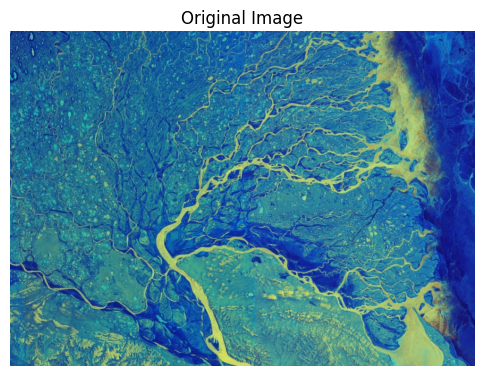

In [5]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

url = "https://media2.spaceref.com/news/2019/esa_earth_from_space_Lena_River_Delta_Russia_062119_945.jpg"

response = requests.get(url)
img = Image.open(BytesIO(response.content))

I = np.array(img)

plt.figure(figsize=(6,6))
plt.imshow(I)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Step 2 — Convert to grayscale (intensity image)

Many spatial filters (including high-boost and other convolution kernels) are easiest to explain on a
single-band grayscale image.  
Grayscale represents **intensity values**, making the effect of edge enhancement clearer.

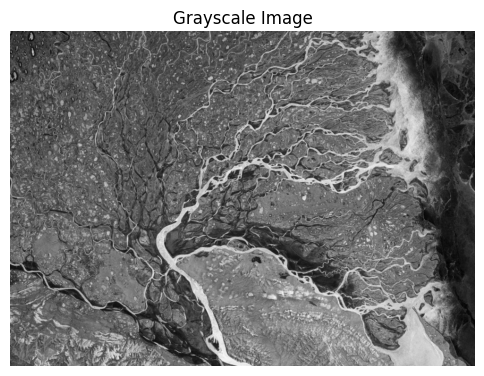

In [6]:
# Convert to grayscale
img_gray = img.convert("L")

# Convert to numpy array
I = np.array(img_gray, dtype=float)

plt.figure(figsize=(6,6))
plt.imshow(I, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Low-pass filtering smooths the image by removing high-frequency details such as edges and fine textures.
This blurred image represents the low-frequency component of the image.

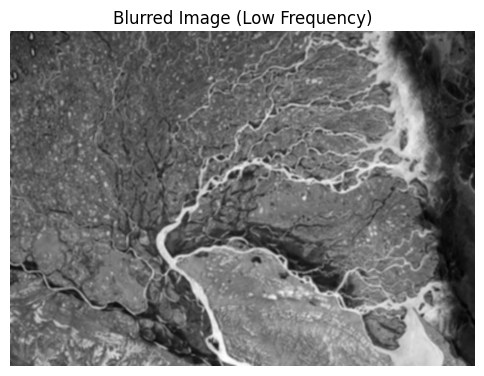

In [21]:
from scipy.signal import convolve2d

# simple blur kernel
blur_kernel = np.ones((5,5)) / 25

blur = convolve2d(I, blur_kernel, mode='same', boundary='symm')

plt.figure(figsize=(6,6))
plt.imshow(blur, cmap='gray')
plt.title("Blurred Image (Low Frequency)")
plt.axis("off")
plt.show()

The high-frequency component is obtained by subtracting the blurred image from the original image.
This reveals edges and fine textures.

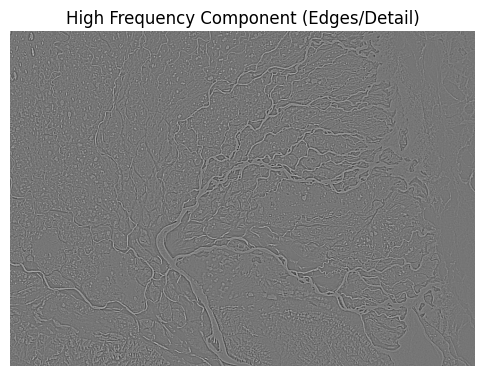

In [22]:
detail = I - blur

plt.figure(figsize=(6,6))
plt.imshow(detail, cmap='gray')
plt.title("High Frequency Component (Edges/Detail)")
plt.axis("off")
plt.show()

High-boost filtering enhances edges by adding the amplified detail component back to the original image.

g = f + k(f − f_blur)

Where:
f = original image
f_blur = blurred image
k = boost factor

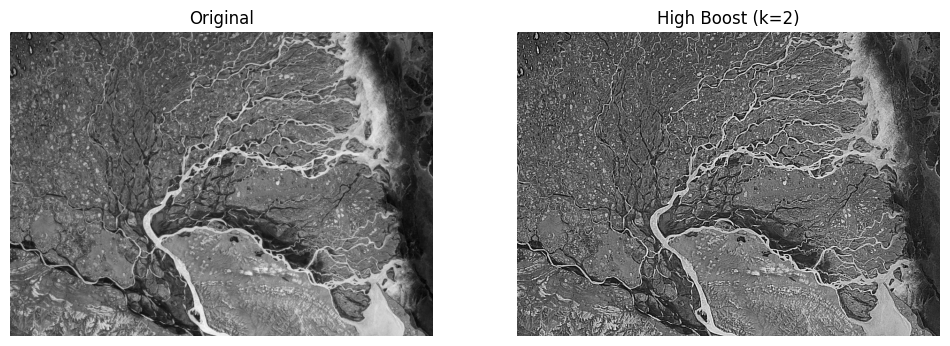

In [23]:
k = 2

highboost = I + k * detail
highboost = np.clip(highboost, 0, 255)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(I, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(highboost, cmap='gray')
plt.title(f"High Boost (k={k})")
plt.axis("off")

plt.show()

## Step 3 — Define the high-boost convolution kernel

A convolution kernel is a small matrix of weights that slides over the image.
Each output pixel is computed as a weighted sum of the pixel and its neighbors.

A common 3×3 high-boost kernel is:

\[
\begin{bmatrix}
-1 & -1 & -1\\
-1 & 9  & -1\\
-1 & -1 & -1
\end{bmatrix}
\]

A generalized form is:

\[
\begin{bmatrix}
-1 & -1 & -1\\
-1 & (A+8)  & -1\\
-1 & -1 & -1
\end{bmatrix}
\]

Increasing **A** increases sharpening strength, but too large A can create halos and amplify noise.

In [11]:
A = 1

kernel_highboost = np.array([
[-1, -1, -1],
[-1, A+8, -1],
[-1, -1, -1]
])

print("High-Boost Kernel:\n", kernel_highboost)

High-Boost Kernel:
 [[-1 -1 -1]
 [-1  9 -1]
 [-1 -1 -1]]


## Step 4 — Apply the high-boost filter for different A values

Now I apply the kernel-based high-boost filter using multiple values of **A**
to show how sharpening strength changes.

Important note:
- High-boost filtering can create values below 0 or above 255.
- To display the result properly, we **clip** values into the valid range [0, 255].

We keep a consistent display scale (`vmin=0`, `vmax=255`) so the comparison is fair.

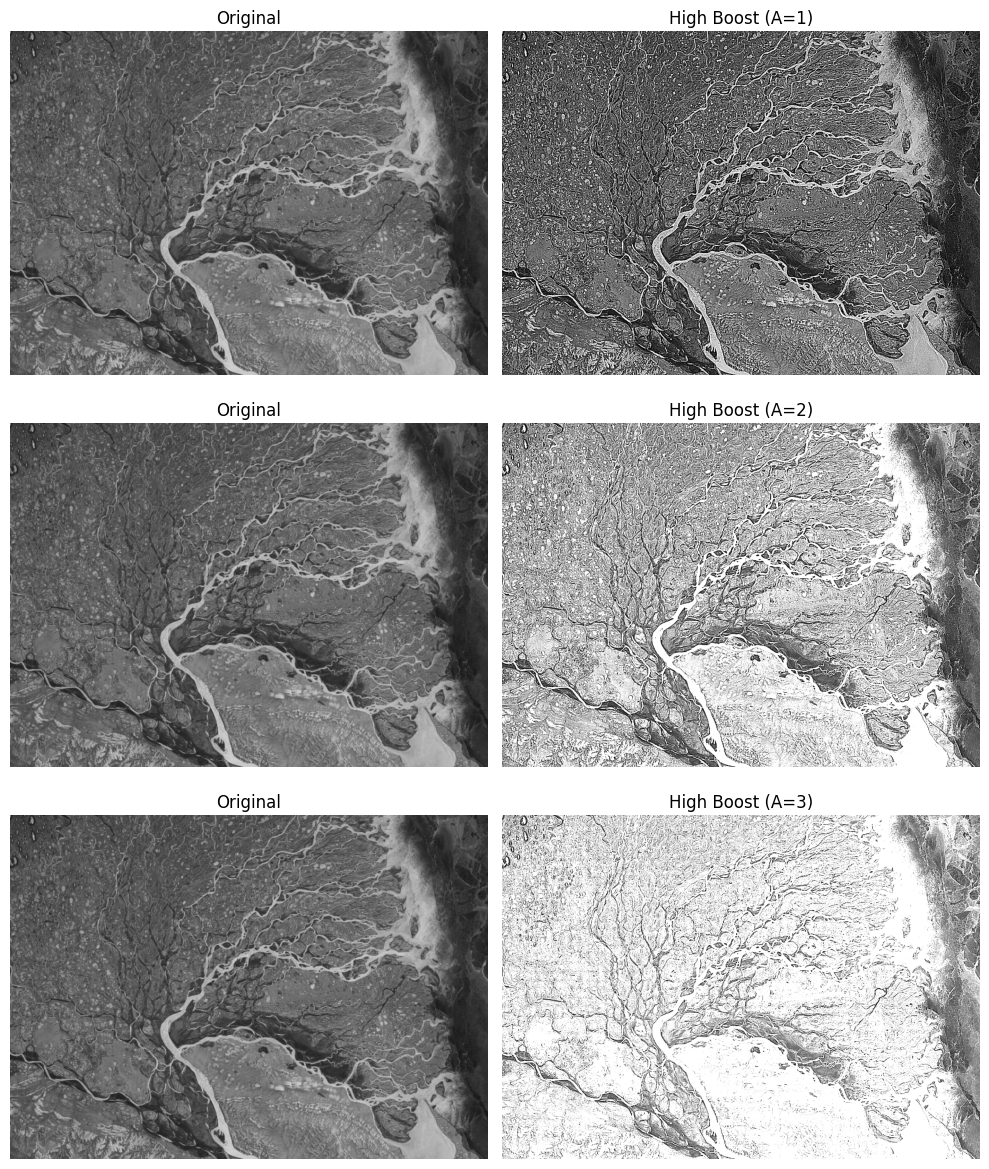

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

A_values = [1,2,3]

plt.figure(figsize=(10,12))

for i, A in enumerate(A_values):

    K = np.array([[-1,-1,-1],

                  [-1,A+8,-1],
                  [-1,-1,-1]], dtype=float)

    hb = convolve2d(I, K, mode='same', boundary='symm')

    # Prevent overflow
    hb = np.clip(hb, 0, 255)

    # Original
    plt.subplot(len(A_values),2,2*i+1)
    plt.imshow(I, cmap='gray', vmin=0, vmax=255)
    plt.title("Original")
    plt.axis('off')

    # High Boost
    plt.subplot(len(A_values),2,2*i+2)
    plt.imshow(hb, cmap='gray', vmin=0, vmax=255)
    plt.title(f"High Boost (A={A})")
    plt.axis('off')

plt.tight_layout()
plt.show()

Conclusion

High-boost filtering enhances edges and textures by amplifying high-frequency components in an image.

Increasing the parameter A or k increases sharpening strength, but excessive values can introduce noise and halo artifacts.

This technique is widely used in remote sensing, computer vision, and image enhancement.

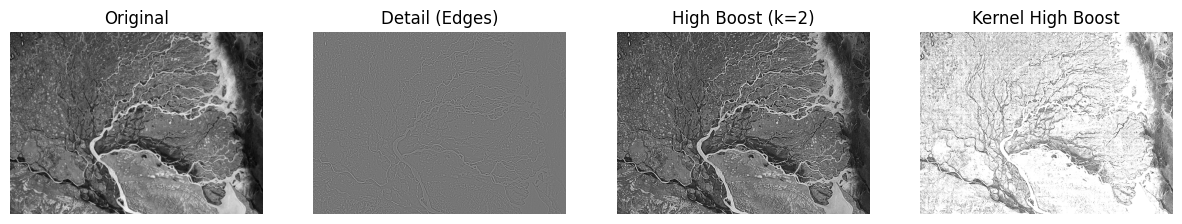

In [24]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(I, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(detail, cmap="gray")
plt.title("Detail (Edges)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(highboost, cmap="gray")
plt.title("High Boost (k=2)")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(hb, cmap="gray")
plt.title("Kernel High Boost")
plt.axis("off")

plt.show()

## Applications of High-Boost Filtering

High-boost filtering is commonly used in:

• Remote sensing (enhancing land boundaries and terrain features)  
• Medical imaging (highlighting edges in X-ray or MRI scans)  
• Computer vision preprocessing  
• Satellite image interpretation